# GrainID modified U-net Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import numpy as np
import tifffile
import cv2
import random
import matplotlib.pyplot as plt
import io
from PIL import Image

In [ ]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class DownConv(nn.Module):
    """Maxpool downscaling => double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class UpConv(nn.Module):
    """Upscaling => double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels , in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x1, x2):
        x1 = self.up(x1)
        # CHW input
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = DownConv(64, 128)
        self.down2 = DownConv(128, 256)
        self.down3 = DownConv(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = DownConv(512, 1024 // factor)
        self.up1 = UpConv(1024, 512 // factor, bilinear)
        self.up2 = UpConv(512, 256 // factor, bilinear)
        self.up3 = UpConv(256, 128 // factor, bilinear)
        self.up4 = UpConv(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x6 = self.up1(x5, x4)
        x7 = self.up2(x6, x3)
        x8 = self.up3(x7, x2)
        x9 = self.up4(x8, x1)
        y_out = self.outc(x9)
        return y_out

# Load Dataset

In [ ]:
get_ipython().system('pip install tifffile')

In [ ]:
class GrainDistanceDataset(Dataset):
    def __init__(self, input_file_path, target_file_path, patch_size=256, transform=None, target_transform=None):
        self.input_file_path = input_file_path
        self.target_file_path = target_file_path
        self.patch_size = patch_size
        self.transform = transform
        self.target_transform = target_transform

        if not os.path.exists(self.input_file_path):
            raise FileNotFoundError(f"Input file not found: {self.input_file_path}")
        if not os.path.exists(self.target_file_path):
            raise FileNotFoundError(f"Target file not found: {self.target_file_path}")

        # Pre-load to determine number of slices if 3D
        _temp_input = tifffile.imread(self.input_file_path)
        _temp_target = tifffile.imread(self.target_file_path)

        # Assuming tifffile.imread returns (H, W) for 2D or (H, W, D) for 3D
        self.num_input_slices = _temp_input.shape[-1] if _temp_input.ndim == 3 else 1
        self.num_target_slices = _temp_target.shape[-1] if _temp_target.ndim == 3 else 1

        self.total_effective_samples = max(self.num_input_slices, self.num_target_slices)
        print(f"Dataset initialized: Input has {self.num_input_slices} slices, Target has {self.num_target_slices} slices. Total effective samples (slices): {self.total_effective_samples}")

    def __len__(self):
        return self.total_effective_samples

    def __getitem__(self, idx):
        # Load images directly from the stored file paths
        input_image = tifffile.imread(self.input_file_path)
        target_image = tifffile.imread(self.target_file_path)

        # Handle 3D images by selecting a random slice if multiple slices exist
        if input_image.ndim == 3: # Assuming (H, W, D) from previous observation
            # Use a slice index from the current iteration if it's within bounds
            slice_idx = idx % input_image.shape[-1]
            input_image = input_image[:, :, slice_idx] # Now (H, W)
        if target_image.ndim == 3: # Assuming (H, W, D)
            # Use a slice index from the current iteration for target
            slice_idx_target = idx % target_image.shape[-1]
            target_image = target_image[:, :, slice_idx_target] # Now (H, W)

        # Convert to float32
        input_image = input_image.astype(np.float32)
        target_image = target_image.astype(np.float32)

        # Normalize input image to [0, 1]
        input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min() + 1e-8) # Added epsilon for stability

        # Add channel dimension if single channel (H, W) -> (1, H, W)
        if input_image.ndim == 2:
            input_image = np.expand_dims(input_image, axis=0)
        # If target image has multiple channels, take the first one and ensure (1, H, W)
        # For CrossEntropyLoss, target should be (H, W) or (N, H, W), so it's fine if it's (1, H, W) and then squeezed.
        if target_image.ndim == 3 and target_image.shape[0] not in [1, 3, 4]: # Assuming (H, W, C) where C is not a channel count
            target_image = target_image[:,:,0] # Take first channel if it's (H,W,C)
            target_image = np.expand_dims(target_image, axis=0) # Now (1, H, W)
        elif target_image.ndim == 2:
            target_image = np.expand_dims(target_image, axis=0) # Now (1, H, W)


        # Resizing to be a multiple of patch_size if needed
        h, w = input_image.shape[-2:] # (C, H, W)
        new_h = (h // self.patch_size) * self.patch_size
        new_w = (w // self.patch_size) * self.patch_size
        if new_h == 0 or new_w == 0:
            new_h = self.patch_size
            new_w = self.patch_size

        if h != new_h or w != new_w:
            input_image_resized = cv2.resize(input_image[0], (new_w, new_h), interpolation=cv2.INTER_LINEAR)[np.newaxis, ...]
            target_image_resized = cv2.resize(target_image[0], (new_w, new_h), interpolation=cv2.INTER_NEAREST)[np.newaxis, ...]
            input_image = input_image_resized
            target_image = target_image_resized

        # Extract random patch
        max_h = input_image.shape[-2] - self.patch_size
        max_w = input_image.shape[-1] - self.patch_size

        if max_h < 0 or max_w < 0: # Image is smaller than patch size, return whole image
            input_patch = input_image
            target_patch = target_image
        else:
            top = random.randint(0, max_h)
            left = random.randint(0, max_w)
            input_patch = input_image[:, top : top + self.patch_size, left : left + self.patch_size]
            target_patch = target_image[:, top : top + self.patch_size, left : left + self.patch_size]

        # Apply transformations if any
        if self.transform:
            input_patch = self.transform(input_patch)
        if self.target_transform:
            target_patch = self.target_transform(target_patch)

        # Convert to PyTorch tensors (already in C, H, W format from expand_dims)
        input_tensor = torch.from_numpy(input_patch)
        target_tensor = torch.from_numpy(target_patch)

        return input_tensor, target_tensor


In [ ]:
input_file_path = '/content/dataset/default/triax.8.eps=-0.07.spheres_image_gaussian=08_noise=30.tif'
target_file_path = '/content/dataset/truth/heightmap.tif'

print(f"Input file path: {input_file_path}")
print(f"Target file path: {target_file_path}")

Input file path: /content/dataset/default/triax.8.eps=-0.07.spheres_image_gaussian=08_noise=30.tif
Target file path: /content/dataset/truth/heightmap.tif


In [ ]:
dataset = GrainDistanceDataset(input_file_path, target_file_path)
input_sample, target_sample = dataset[0]

print(f"Input sample shape: {input_sample.shape}")
print(f"Target sample shape: {target_sample.shape}")

Dataset initialized: Input has 125 slices, Target has 284 slices. Total effective samples (slices): 284
Input sample shape: torch.Size([1, 256, 256])
Target sample shape: torch.Size([1, 256, 256])


### Visualize a Random Input-Target Pair

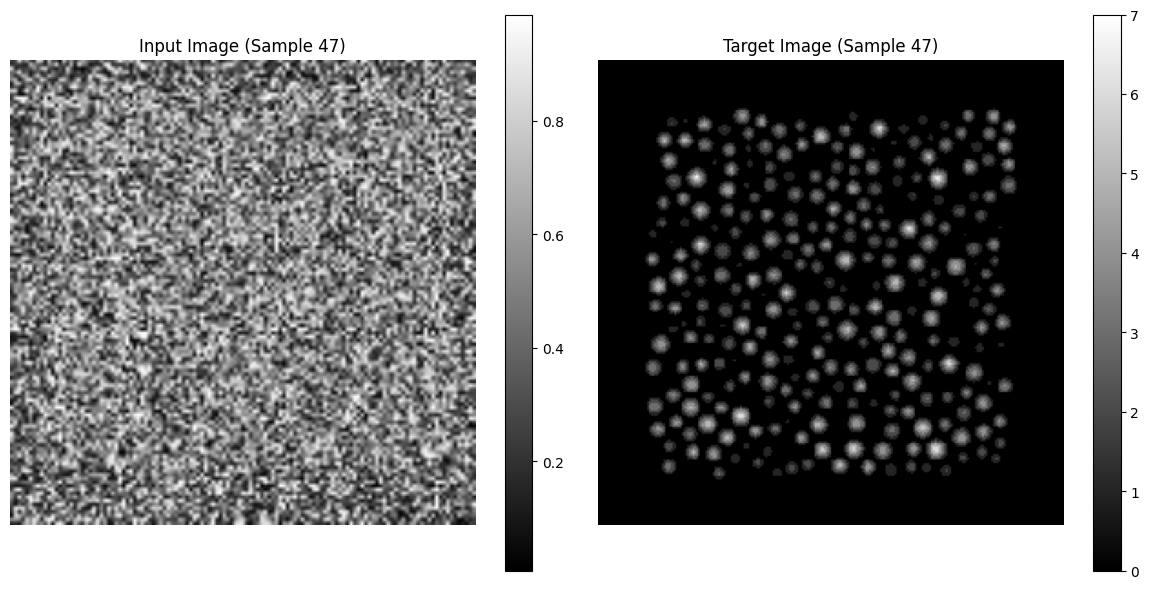

In [ ]:
# Get a random index from the dataset
random_idx = random.randint(0, len(dataset) - 1)
input_image_display, target_image_display = dataset[random_idx]

# Assuming single channel images, squeeze the channel dimension for matplotlib display
input_image_display = input_image_display.squeeze(0).cpu().numpy()
target_image_display = target_image_display.squeeze(0).cpu().numpy()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(input_image_display, cmap='gray')
plt.title(f'Input Image (Sample {random_idx})')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(target_image_display, cmap='gray') # Assuming target is also grayscale, or needs a specific colormap
plt.title(f'Target Image (Sample {random_idx})')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


## Setup Data Loader and Model for Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)


n_channels = input_sample.shape[0]
n_classes = 2

model = UNet(n_channels=n_channels, n_classes=n_classes, bilinear=True).to(device)

print(f"UNet model instantiated with {n_channels} input channels and {n_classes} output classes.")
print(f"Model moved to {device}")


Using device: cpu
UNet model instantiated with 1 input channels and 2 output classes.
Model moved to cpu


## Training Loop

In [ ]:
class CombinedLoss(nn.Module):

    def __init__(self, alpha=0.7, beta=0.3):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse = nn.MSELoss()

    def gradient_loss(self, pred, target):
        # This gradient calculation assumes a 5D input tensor (Batch, Channels, Depth, Height, Width)
        # which might not be compatible with the current UNet output (Batch, N_Classes, Height, Width)
        # and the GrainDistanceDataset output (C, H, W).
        grad_pred_z = pred[:, :, 1:, :, :] - pred[:, :, :-1, :, :]
        grad_target_z = target[:, :, 1:, :, :] - target[:, :, :-1, :, :]

        grad_pred_y = pred[:, :, :, 1:, :] - pred[:, :, :, :-1, :]
        grad_target_y = target[:, :, :, 1:, :] - target[:, :, :, :-1, :]

        grad_pred_x = pred[:, :, :, :, 1:] - pred[:, :, :, :, :-1]
        grad_target_x = target[:, :, :, :, 1:] - target[:, :, :, :, :-1]

        loss = (self.mse(grad_pred_z, grad_target_z) +
                self.mse(grad_pred_y, grad_target_y) +
                self.mse(grad_pred_x, grad_target_x)) / 3

        return loss

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        grad_loss = self.gradient_loss(pred, target)
        return self.alpha * mse_loss + self.beta * grad_loss


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs = inputs.to(device)
        # For CrossEntropyLoss, targets usually need to be of type long and contain class indices.
        # If your targets are float distance maps, you might need to convert them to class labels.
        targets = targets.squeeze(1) # Remove channel dimension, now (B, H, W) float
        # Convert float distance map to binary class labels (0 or 1) by thresholding
        # Assuming normalized distance map where values above a threshold indicate a foreground class.
        # This threshold (0.5) might need tuning based on the actual heightmap data.
        targets = (targets > 0.5).long().to(device) # Threshold to 0 or 1, then convert to long

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            # For CrossEntropyLoss, targets usually need to be of type long and contain class indices.
            targets = targets.squeeze(1) # Remove channel dimension, now (B, H, W) float
            # Convert float distance map to binary class labels (0 or 1) by thresholding
            targets = (targets > 0.5).long().to(device) # Threshold to 0 or 1, then convert to long

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()

    return total_loss / len(dataloader)


In [ ]:
criterion = nn.CrossEntropyLoss()

if 'model' not in locals():
    model = UNet(n_channels=1, n_classes=2)

optimizer = optim.SGD(model.parameters(), lr=0.005)


In [ ]:
# should match the paper
batch_size = 96
num_epochs = 150

print(f"Batch size: {batch_size}")
print(f"Number of epochs: {num_epochs}")


Batch size: 96
Number of epochs: 150


In [ ]:
def train_model(model, train_dataloader, criterion, optimizer, num_epochs, device):
    train_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        # Train
        current_train_loss = train_epoch(model, train_dataloader, criterion, optimizer, device)
        train_losses.append(current_train_loss)
        print(f"  Train Loss: {current_train_loss:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, train_losses

trained_model, losses = train_model(model, train_dataloader, criterion, optimizer, num_epochs, device)


# Display Results

In [ ]:
inference_dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
print("Inference DataLoader created successfully with batch_size=1 and shuffle=False.")

Inference DataLoader created successfully with batch_size=1 and shuffle=False.


In [ ]:
# Set the trained_model to evaluation mode
trained_model.eval()

# Create an empty list called frames to store the generated image frames.
frames = []

# Iterate through the inference_dataloader batch by batch.
for i, (inputs, targets) in enumerate(inference_dataloader):
    # Move the inputs and targets to the device
    inputs = inputs.to(device)
    targets_original = targets.clone() # Keep original targets for display
    targets = targets.to(device)

    # Squeeze the targets tensor to remove the channel dimension, resulting in a shape like (B, H, W).
    # Convert the float targets to binary class labels (0 or 1) by thresholding at 0.5 and casting to long
    targets = (targets.squeeze(1) > 0.5).long() # Already (B, H, W)

    # Disable gradient calculations using torch.no_grad().
    with torch.no_grad():
        # Pass the inputs through the trained_model to get outputs.
        outputs = trained_model(inputs)

    # Apply torch.argmax along the channel dimension (dim=1) to the outputs to get the predicted segmentation masks.
    # Move these predictions to the CPU and convert them to a NumPy array.
    predictions = torch.argmax(outputs, dim=1).cpu().numpy().squeeze(0) # (H, W)

    # Move the inputs and targets to the CPU and convert them to NumPy arrays,
    # squeezing any extra dimensions if present, for visualization.
    input_image_np = inputs.cpu().numpy().squeeze(0).squeeze(0) # (H, W)
    # Use targets_original for the ground truth display as it's the original float distance map
    ground_truth_np = targets_original.cpu().numpy().squeeze(0).squeeze(0) # (H, W)

    # Create a Matplotlib figure with three subplots.
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Add titles to each subplot
    axes[0].imshow(input_image_np, cmap='gray')
    axes[0].set_title(f'Input Image (Slice {i})')

    axes[1].imshow(ground_truth_np, cmap='gray')
    axes[1].set_title(f'Ground Truth (Slice {i})')

    axes[2].imshow(predictions, cmap='gray')
    axes[2].set_title(f'Prediction (Slice {i})')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    frames.append(img)
    plt.close(fig)

print(f"Finished generating {len(frames)} frames.")

Generating frames...
Finished generating 284 frames.


In [ ]:
gif_path = 'segmentation_output.gif'

if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=100,
        loop=0
    )
    print(f"GIF saved to {gif_path}")
else:
    print("No frames were generated to create a GIF.")

GIF saved to segmentation_output.gif


In [ ]:
model_save_dir = 'trained_models'
os.makedirs(model_save_dir, exist_ok=True)

model_path = os.path.join(model_save_dir, 'grainId.pth')

torch.save(trained_model.state_dict(), model_path)

print(f"Trained model saved to: {model_path}")